# A short IV Curve plot for two step method:
- Used perovskite: FAPbI3
- 

In [1]:
import numpy as np 
import matplotlib.pyplot as pyplot
from plot_module.solsim_analyzer import solarSimulator

In [2]:
folderPath_thickC60 = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Compare_2Step_Thickness/Thick_C60/importVSC'
folderPath_thinC60 = '/Users/ruodongyang/Documents/Resilio_Sync/TUM Master Physik/Pervoskite Space(Master)/Data/SolSim/MA_Data/Compare_2Step_Thickness/Thin_C60/importVSC'

In [3]:
thick = solarSimulator(folderPath=folderPath_thickC60)
thin = solarSimulator(folderPath=folderPath_thinC60)
thick.loadFolderData()
thin.loadFolderData()

[-0.40345153 -0.83318321 -1.23789853 -1.63198311 -2.02649129 -2.42471704
 -2.82949145 -3.24788998 -3.67242231 -4.09764449 -4.53605434 -4.97886648
 -5.40847313 -5.8106723  -6.19993463 -6.558034   -6.88129638 -7.17273398
 -7.42669926 -7.62794458 -7.78131054 -7.9041185  -7.97184405 -7.99716683
 -8.00083409 -7.97114629 -7.9189113  -7.83651899 -7.74234178 -7.64728546
 -7.52580021 -7.38963681 -7.25245896 -7.11162899 -6.96499549 -6.81199507
 -6.65265947 -6.48039578 -6.31254182 -6.14573976 -5.97126317 -5.79025804
 -5.61343132 -5.4327945  -5.24782878 -5.06221311 -4.8727421  -4.68653079
 -4.49747164 -4.30382444 -4.11305209 -0.24844948 -0.05521688  0.1379329
  0.33081273  0.52320666  0.71534531  0.90645559  1.09819469  1.28836505
  1.47848472  1.66908111  1.85784508  2.04590575  2.23499278  2.42281768
  2.61060514  2.79534123  2.97882009  3.1633529   3.35167089]
PIN_1_px4_Light_forward_0
[-0.38209838 -0.96722913 -1.51946939 -2.00993065 -2.46399398 -2.8570021
 -3.26184694 -3.65163898 -4.0289273  -

#### Verify the PCE, FF, etc.

In [4]:
print(thin.FF, thick.FF)
print(thin.PCE, thick.PCE)
print(thin.Isc, thick.Isc)
print(thin.Voc, thick.Voc)

[0.4897316040377935, 0.3389884398409986, 0.40081571305002445, 0.4061149860337544, 0.3235185754636077] [0.5727213116451726, 0.45470347284360413, 0.657961904868719, 0.40121460417198584, 0.45791874416557127, 0.6213160065016782, 0.6154690264146018]
[5.92870571387145, 2.930947354355344, 2.9371253212729114, 3.844062815712447, 0.08386785349711391] [10.66333387748924, 10.76338247986146, 13.953269356847253, 10.938685894088609, 12.372058016877636, 15.657749591173697, 15.207230184153303]
[0.00157766, 10.989443037974683, 9.684316455696203, 9.211860759493671, 7.537189873417721] [0.00135226, 22.38151898734177, 18.474303797468355, 22.29, 23.849367088607597, 21.95379746835443, 22.104177215189875]
[-0.454839, -0.590323, -0.567742, -0.770968, -0.0258065] [-0.816129, -0.793548, -0.86129, -0.917742, -0.85, -0.86129, -0.83871]


/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_14594/1932180230.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Batch", y="Value", data=dfi, ax=ax, palette=palette)
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_14594/1932180230.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Batch", y="Value", data=dfi, ax=ax, palette=palette)
/var/folders/gk/j7sbhfc93v5gxyqp6ltt1dqc0000gn/T/ipykernel_14594/1932180230.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Batch", y="Value", data=dfi, ax=ax, palette=p

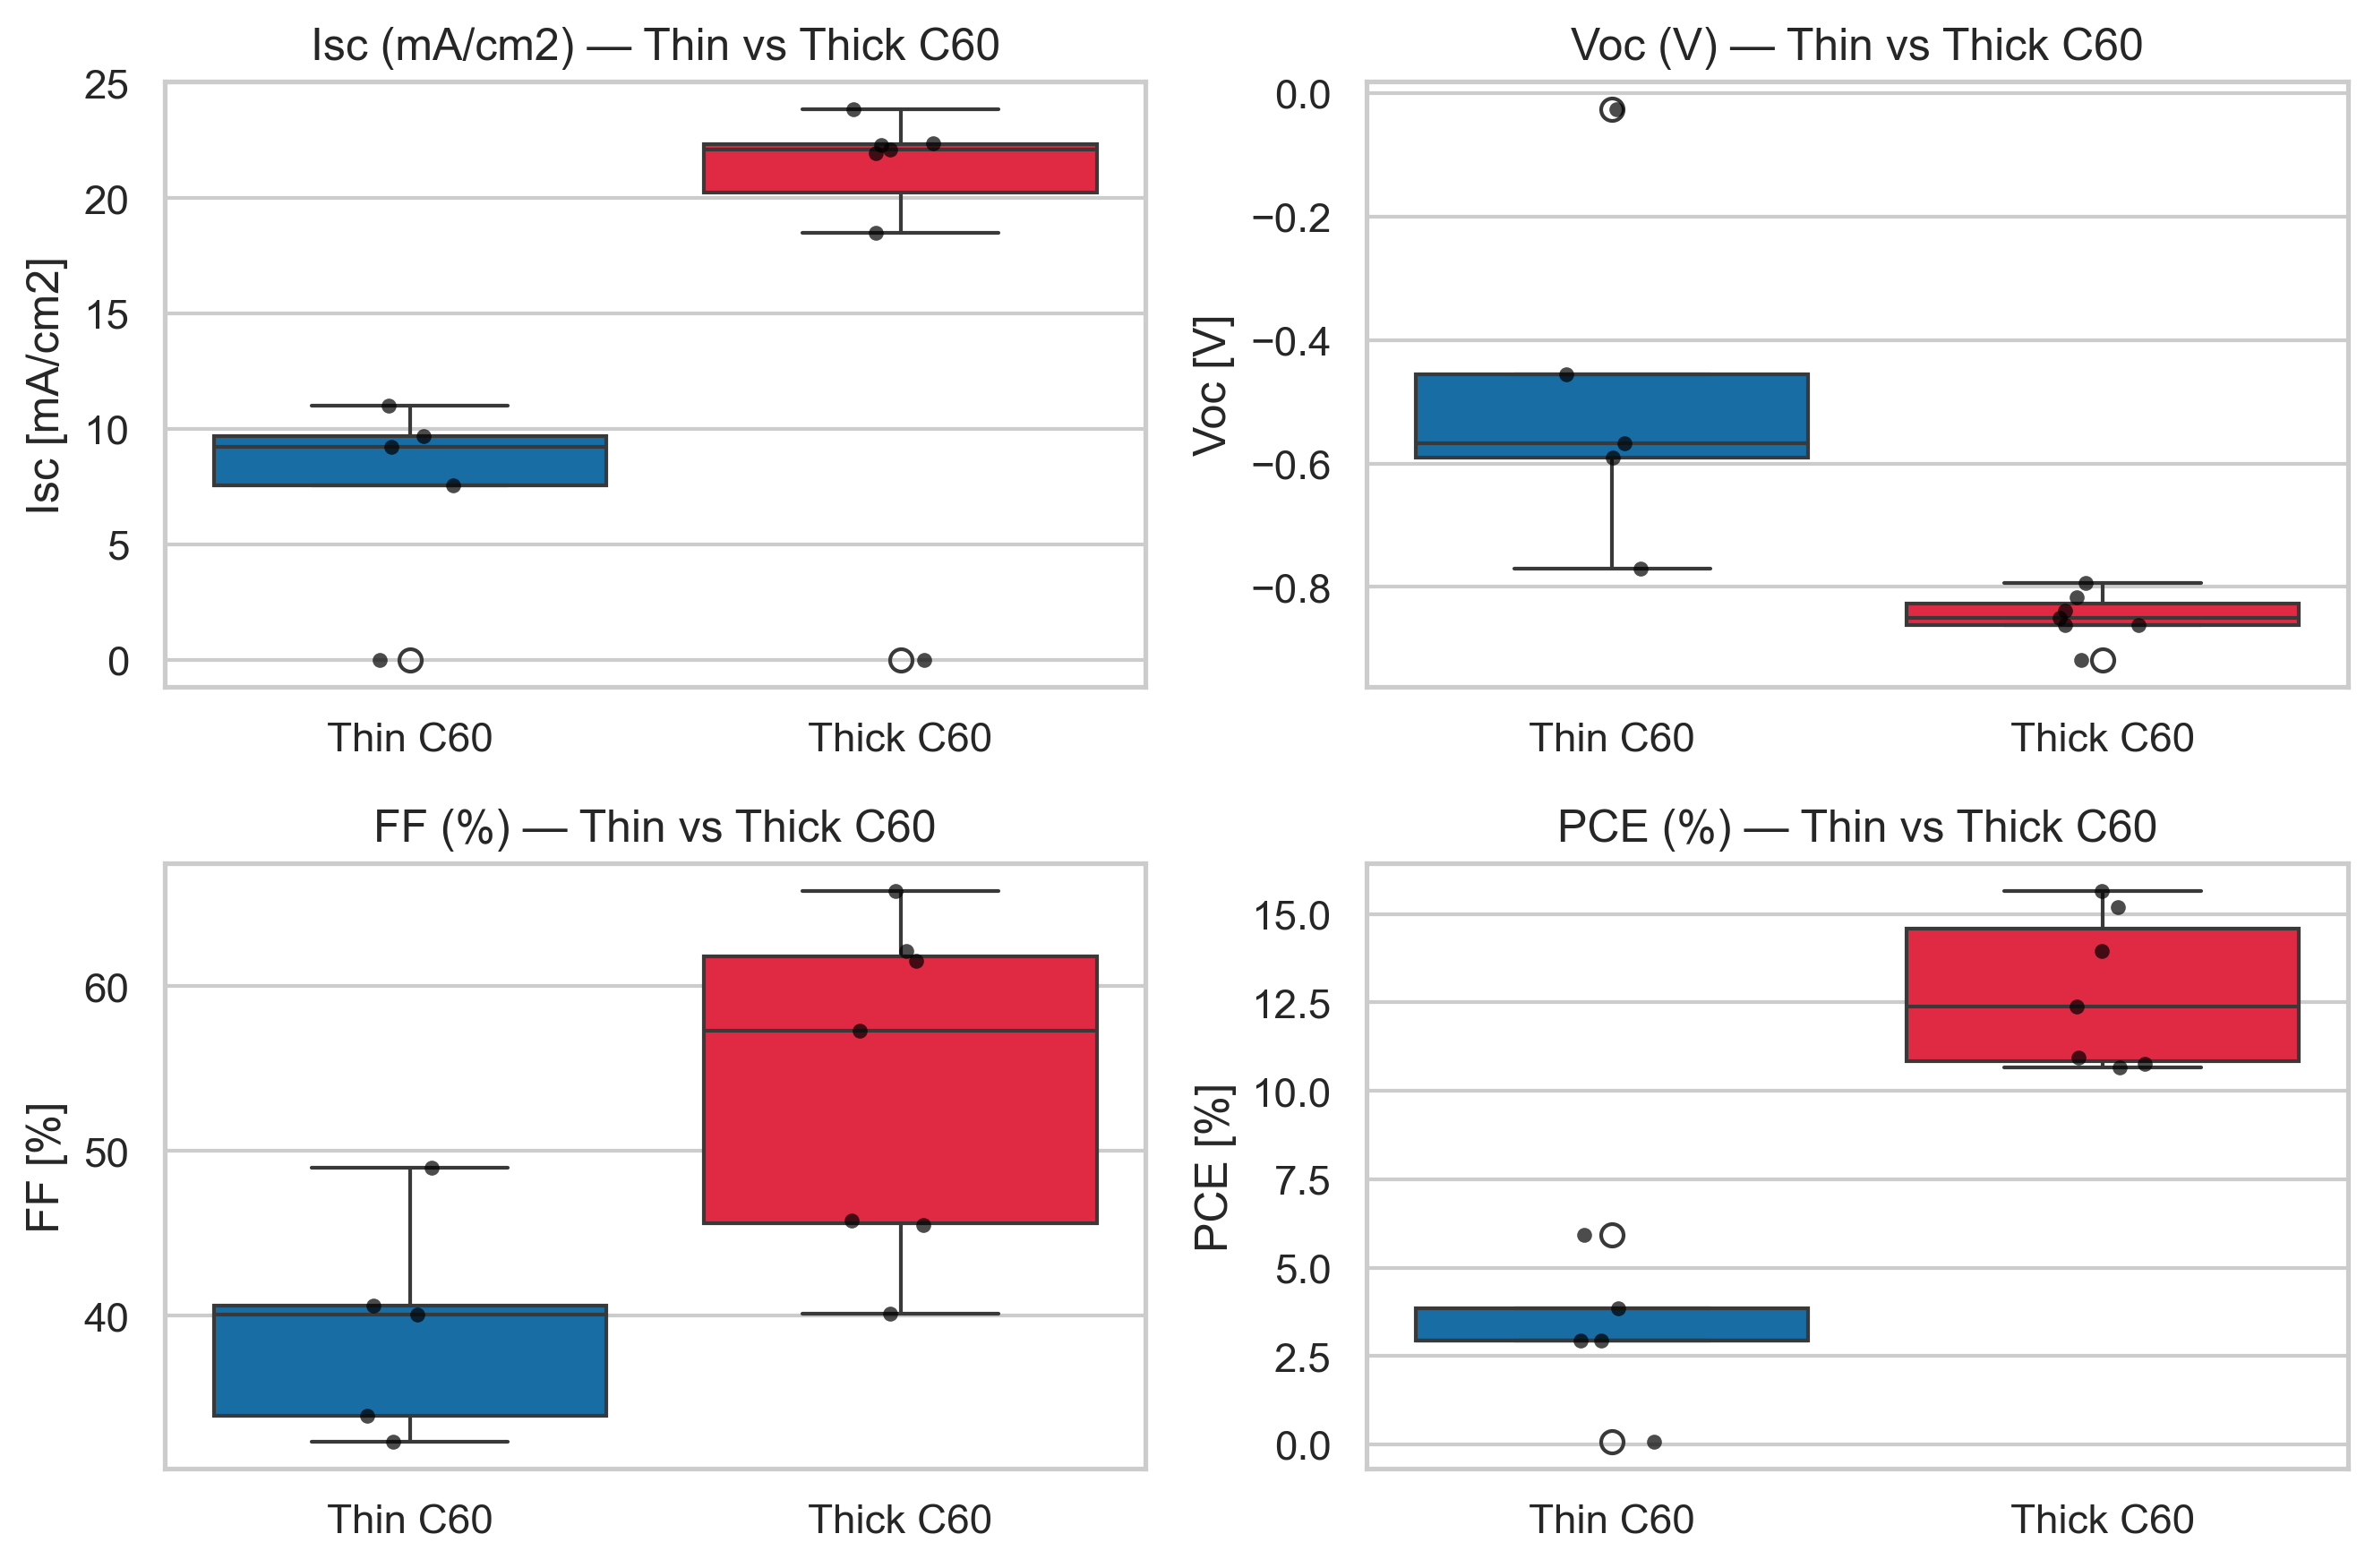

In [7]:
#CODEX: WRITE THE SCRIPT HERE:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build a tidy DataFrame with metrics for Thin vs Thick
rows = []
for batch_name, sim in [("Thin C60", thin), ("Thick C60", thick)]:
    # Isc [mA/cm2]
    rows += [{"Batch": batch_name, "Metric": "Isc [mA/cm2]", "Value": float(v)} for v in sim.Isc]
    # Voc [V]
    rows += [{"Batch": batch_name, "Metric": "Voc [V]", "Value": float(v)} for v in sim.Voc]
    # FF as percent
    rows += [{"Batch": batch_name, "Metric": "FF [%]", "Value": float(v)*100.0} for v in sim.FF]
    # PCE already in percent
    rows += [{"Batch": batch_name, "Metric": "PCE [%]", "Value": float(v)} for v in sim.PCE]
df = pd.DataFrame(rows)

# Plot: 2x2 boxplots with jittered points overlay
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(9, 6), dpi=300)
axes = axes.flatten()
metrics = ["Isc [mA/cm2]", "Voc [V]", "FF [%]", "PCE [%]"]
palette = ["#0072BD", "#FF0A2D"]

for ax, metric in zip(axes, metrics):
    dfi = df[df["Metric"] == metric]
    sns.boxplot(x="Batch", y="Value", data=dfi, ax=ax, palette=palette)
    sns.stripplot(x="Batch", y="Value", data=dfi, ax=ax, color="black", size=4, jitter=True, alpha=0.7)
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    _mtitle = metric.replace(" [", " (").replace("]", ")")
    ax.set_title(f"{_mtitle} — Thin vs Thick C60")

plt.tight_layout()
plt.savefig("Thin_vs_Thick_C60_boxplots.png", bbox_inches="tight")
plt.show()
